# Chapter 13 — Pulsars

!!! info "Before you start"
    **Prerequisites:** Ch 10 (Accessing Open Archives) · **Maths Lab:** [Lab B (Matched Filtering)](32_mathslab_matched_filtering.ipynb) · **~50 min** · **Intermediate**

In **Chapter 11** we used the 21 cm hydrogen line to weigh the Galaxy, and in
**Chapter 10** we learned to pull real bytes out of public archives. This
chapter turns to one of radio astronomy's most spectacular discoveries: the
**pulsar** — a rapidly rotating, intensely magnetised **neutron star** that
sweeps a beam of radio emission across the sky like a lighthouse. Each time the
beam crosses our line of sight we record a pulse, and the pulses arrive with a
regularity that rivals atomic clocks.

Pulsars are also a beautiful laboratory for a piece of physics that pervades all
of radio astronomy: a radio signal does not travel through the interstellar
medium (ISM) at a single speed. The tenuous plasma between the stars is
**dispersive** — low frequencies arrive *later* than high frequencies — and the
amount of delay encodes how much plasma the signal crossed. Measuring and
*removing* that delay (**de-dispersion**) is the central data-reduction step in
pulsar astronomy, and it is the heart of this chapter.

### Learning goals

By the end of this chapter you will be able to:

- describe what a pulsar **is** — a rotating neutron star — and the
  **lighthouse model** that produces the pulses;
- recount the **1967–68 discovery** by Jocelyn Bell and Antony Hewish;
- explain how the cold ISM plasma **disperses** a broadband pulse, and write
  down the delay law $t \propto \mathrm{DM}\cdot\nu^{-2}$ with the **dispersion
  measure** (DM);
- **de-disperse** a dynamic spectrum by shifting frequency channels, and
  **fold** a time series at the pulse period to build signal-to-noise and
  recover the average **pulse profile**;
- say in one paragraph what **pulsar timing** is and why it matters.

This is a **scaffold** chapter. The narrative and the core simulation run
end-to-end on the base environment with **no network** and **without** the
optional `pulsar` extra. A few cells are marked `# TODO` — they run as-is but
are written for you to extend, and a closing section points at the real tools
(`pint-pulsar`, `your`) and archives (HEASARC, EPN) once you install them.

## The history: "a rapidly pulsating radio source"

In the summer of 1967, **Jocelyn Bell** (now Dame Jocelyn Bell Burnell), a
graduate student, was operating a new low-frequency (81.5 MHz) array at the
Mullard Radio Astronomy Observatory near Cambridge, built to study the
scintillation of compact radio sources through the solar wind. On the
chart-recorder paper she noticed "a bit of scruff" — a signal that did not look
like a known source or like terrestrial interference, and that recurred at the
same sidereal time. With faster recording she resolved it into a train of
pulses arriving every **1.337 seconds**, astonishingly regular.

The team briefly and half-jokingly labelled the source **LGM-1** ("Little Green
Men"), wary that such a precise clock might be artificial — before finding more
such sources around the sky and concluding the mechanism was natural. The
announcement was:

> **Hewish, A., Bell, S. J., Pilkington, J. D. H., Scott, P. F. &
> Collins, R. A. (1968).** *Observation of a Rapidly Pulsating Radio Source.*
> **Nature 217, 709.**
> [DOI: 10.1038/217709a0](https://doi.org/10.1038/217709a0)

The paper reported a source with a pulse period of $1.33730109$ s held to
extraordinary precision, and — crucially for *this* chapter — noted the
**frequency-dependent arrival time** of the pulses across the receiver band,
consistent with dispersion along an **interstellar** (well beyond the solar
system) path and the electron column it implies, though this alone did not
pin the distance conclusively. The objects were soon identified as
rotating **neutron stars** (Gold 1968; Pacini 1968), the ultra-dense remnants of
massive-star supernovae, only $\sim$20 km across but more massive than the Sun.
The 1974 Nobel Prize in Physics recognised the discovery — controversially
omitting Bell Burnell, the student who first spotted the signal.

## The physics, part 1 — the lighthouse model

A neutron star packs $\sim 1.4\,M_\odot$ into a sphere $\sim$20 km across,
conserving the angular momentum and magnetic flux of its progenitor's core as it
collapses. The result is an object that spins quickly — periods $P$ from
milliseconds to seconds — and carries an enormous magnetic field, $\sim 10^{8}$
to $10^{12}$ gauss. The magnetic axis is generally **misaligned** with the
rotation axis. Charged particles, torn from the surface and accelerated along the
field lines, radiate a narrow beam of coherent radio emission from near the
magnetic poles.

As the star rotates, that beam sweeps around like the beam of a **lighthouse**.
If the beam happens to cross our line of sight, we see one pulse per rotation —
so the **observed pulse period is the neutron star's spin period $P$**. We see a
pulsar only if our sightline intersects the sweeping beam; many neutron stars
beam away from us and are never detected as pulsars.

The pulse we record on any single rotation is faint and noisy. But because the
clock is so stable, we can **stack many rotations on top of each other** —
*folding* the data at the period $P$ — and the random noise averages down while
the (phase-locked) pulse adds up coherently. This is the second pillar of the
chapter, and we will do it explicitly below.

## The physics, part 2 — dispersion by the interstellar medium

The space between the stars is not empty: it contains a cold, tenuous **plasma**
of free electrons. An electromagnetic wave travelling through a cold plasma has a
**refractive index** that depends on frequency, so its **group velocity** is
*less than $c$* and is *smaller at lower frequencies*. A broadband pulse emitted
at one instant therefore arrives **smeared out in time**: the high frequencies
arrive first, the low frequencies trail behind.

For the cold, magnetised but low-density ISM, the time delay of a signal at
frequency $\nu$ relative to infinite frequency is

$$
t(\nu) \;=\; \mathcal{D}\,\cdot\,\mathrm{DM}\,\cdot\,\nu^{-2},
\qquad
\mathcal{D} \;=\; \frac{e^2}{2\pi m_e c} \;\approx\; 4148.808\ \;
\mathrm{MHz^{2}\,cm^{3}\,pc^{-1}\,s},
$$

where $\nu$ is in MHz and the **dispersion measure**

$$
\mathrm{DM} \;=\; \int_0^{d} n_e \,\mathrm{d}l
\qquad [\mathrm{pc\,cm^{-3}}]
$$

is the **column density of free electrons** along the line of sight — literally
the integral of the electron density $n_e$ out to the pulsar's distance $d$. The
constant $\mathcal{D} \approx 4148.808\ \mathrm{MHz^2\,cm^3\,pc^{-1}\,s}$ is the
standard *dispersion constant* used throughout pulsar astronomy (we adopt this
conventional value rather than the slightly different exact physical constant, so
that DMs are comparable across the literature).

The practical consequence: between two frequencies $\nu_\mathrm{hi}$ and
$\nu_\mathrm{lo}$ the pulse is delayed by

$$
\Delta t \;=\; \mathcal{D}\,\cdot\,\mathrm{DM}\,
\left(\nu_\mathrm{lo}^{-2} - \nu_\mathrm{hi}^{-2}\right),
$$

which can be **seconds** across a typical band — far longer than the pulse
itself. If we do nothing, the pulse is washed out. The cure is **de-dispersion**:
shift each frequency channel *back* by the delay $t(\nu)$ so that the pulse lines
up across the band again. The DM is what we must know (or search for) to do it.

## Setup

We work entirely from the **base environment**. The real pulsar toolchain
(`pint-pulsar` for timing, `your` for reading PSRFITS/filterbank files) lives in
the optional `pulsar` extra; we **guard** those imports so the notebook still
runs without them and fall back to a self-contained NumPy simulation. We use
`astropy.units` to keep the dispersion bookkeeping honest, and
`plotting.use_jansky_style()` for consistent figures.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u

from jansky.plotting import use_jansky_style

use_jansky_style()
rng = np.random.default_rng(13)  # reproducible 'randomness' for this chapter

# --- Optional pulsar tooling: guarded so the base env still runs -------------
# `pint-pulsar` (timing) and `your` (PSRFITS / filterbank I/O) ship in the
# optional `pulsar` extra:  uv sync --extra pulsar
HAVE_PINT = False
HAVE_YOUR = False
try:
    import pint  # noqa: F401  (pulsar timing)

    HAVE_PINT = True
except Exception:
    pass
try:
    import your  # noqa: F401  (PSRFITS / filterbank reader)

    HAVE_YOUR = True
except Exception:
    pass

print("pint-pulsar available:", HAVE_PINT)
print("your available:       ", HAVE_YOUR)
if not (HAVE_PINT and HAVE_YOUR):
    print("-> running the self-contained simulation (no network, no pulsar extra).")

pint-pulsar available: True
your available:        True


/home/joe/dev/github/joebarbere/jansky/.venv/lib/python3.12/site-packages/your/formats/psrfits.py:28: SyntaxWarning: invalid escape sequence '\.'
  "(?:\.[0-9]+)?)$"


## The dispersion constant, with units

Let us pin down the constant and a helper for the delay law. We carry units with
`astropy.units` so the exponents are checkable: a delay should come out in
seconds when DM is in $\mathrm{pc\,cm^{-3}}$ and frequencies are in MHz.

In [2]:
# Standard pulsar dispersion constant (the conventional value used in the field).
K_DM = 4148.808 * u.MHz**2 * u.cm**3 / u.pc * u.s


def dispersion_delay(dm, freq, ref_freq=np.inf * u.MHz):
    r"""Cold-plasma dispersion delay  t = K_DM * DM * (freq^-2 - ref_freq^-2).

    Parameters
    ----------
    dm : Quantity [pc / cm^3]
        Dispersion measure (electron column density).
    freq : Quantity [MHz]
        Observing frequency (or array of channel frequencies).
    ref_freq : Quantity [MHz]
        Reference frequency the delay is measured *relative to*. Default is
        infinite frequency (delay measured from the top of the band -> inf).

    Returns
    -------
    Quantity [s]
        Delay of `freq` relative to `ref_freq` (positive = arrives later).
    """
    return (K_DM * dm * (freq**-2 - ref_freq**-2)).to(u.s)


# Sanity check: a DM=50 pulsar, delay across a 300-400 MHz band.
dm_demo = 50.0 * u.pc / u.cm**3
dt_band = dispersion_delay(dm_demo, 300 * u.MHz, ref_freq=400 * u.MHz)
print(f"DM = {dm_demo:.0f}")
print(f"delay of 300 MHz relative to 400 MHz: {dt_band.to(u.ms):.1f}")
print(f"(i.e. the bottom of the band lags the top by ~{dt_band.to(u.ms).value:.0f} ms)")

DM = 50 pc / cm3
delay of 300 MHz relative to 400 MHz: 1008.4 ms
(i.e. the bottom of the band lags the top by ~1008 ms)


## Simulating a dispersed pulsar: the dynamic spectrum

The raw data product of a pulsar observation is a **dynamic spectrum** (also
called a *waterfall* or *filterbank*): intensity as a function of **time** (rows)
and **frequency** (channels). We will build a synthetic one for a pulsar with a
known period $P$ and dispersion measure $\mathrm{DM}$, so that later we can check
that de-dispersion and folding recover exactly what we put in.

Recipe:

1. Lay out a time axis (many samples) and a frequency axis (many channels across
   a band).
2. Define a clean pulse **profile** — a narrow Gaussian in pulse phase — that
   repeats every period $P$.
3. For **each channel**, place the pulse train but **delayed** by the dispersion
   delay $t(\nu)$ for that channel's frequency. High channels barely shift; low
   channels shift a lot. This produces the characteristic **dispersion sweep** —
   a curved streak across the waterfall.
4. Add white radiometer noise.

Everything here is plain NumPy; no files, no network.

In [3]:
# --- Observation parameters --------------------------------------------------
P = 0.5 * u.s  # pulse period (spin period of the neutron star)
DM_true = 30.0 * u.pc / u.cm**3  # true dispersion measure we will try to recover

f_lo, f_hi = 300.0 * u.MHz, 400.0 * u.MHz  # band edges
n_chan = 256  # frequency channels
n_time = 2048  # time samples
t_samp = 2.0 * u.ms  # sampling interval (time per row)

duty = 0.03  # pulse width as a fraction of the period (fractional duty cycle)
snr_amp = 6.0  # single-pulse peak amplitude relative to the noise sigma

# Channel centre frequencies (top channel = highest frequency).
freqs = np.linspace(f_hi.value, f_lo.value, n_chan) * u.MHz
times = (np.arange(n_time) * t_samp).to(u.s)

# Per-channel dispersion delay relative to the TOP of the band.
delays = dispersion_delay(DM_true, freqs, ref_freq=f_hi)
print(
    f"max dispersion delay (bottom channel): {delays.max().to(u.ms):.1f}"
    f"  = {(delays.max() / P).decompose():.2f} periods"
)


def pulse_train(phase_time, period, duty):
    """A repeating Gaussian pulse vs absolute time, peaking at phase 0."""
    # Fractional phase in [-0.5, 0.5) so the Gaussian wraps cleanly.
    phase = ((phase_time / period).decompose().value + 0.5) % 1.0 - 0.5
    sigma = duty  # Gaussian sigma in units of phase
    return np.exp(-0.5 * (phase / sigma) ** 2)


# Build the dispersed waterfall: rows = time, cols = frequency channels.
waterfall = np.empty((n_time, n_chan))
for j in range(n_chan):
    # This channel sees the pulse train shifted LATER by its dispersion delay.
    shifted_time = times - delays[j]
    waterfall[:, j] = snr_amp * pulse_train(shifted_time, P, duty)

# Add white radiometer noise (sigma = 1 by construction).
waterfall += rng.normal(0.0, 1.0, size=waterfall.shape)
print("dispersed dynamic spectrum shape (time, freq):", waterfall.shape)

max dispersion delay (bottom channel): 605.0 ms  = 1.21 periods
dispersed dynamic spectrum shape (time, freq): (2048, 256)


Below, the left panel is the **dispersed waterfall**. Each bright streak is one
rotation of the pulsar, and it is *not vertical*: it curves, arriving later
toward the bottom (low-frequency) channels. That curve is the dispersion sweep,
and its shape — $t \propto \nu^{-2}$ — is the fingerprint of the cold ISM. The
right panel collapses the waterfall over frequency *without* correcting for
dispersion: the pulse is **smeared across many time samples** and nearly lost.

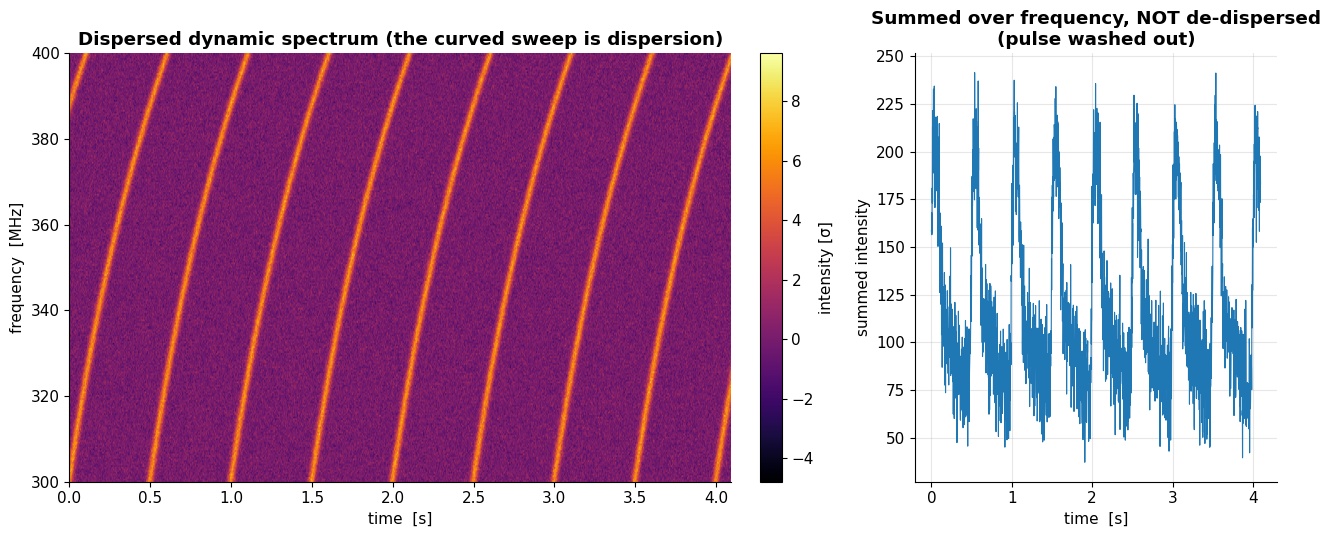

In [4]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13, 5.5), gridspec_kw={"width_ratios": [2, 1]})

# Waterfall: transpose so frequency is on the y-axis, time on the x-axis.
extent = [0, times[-1].value, f_lo.value, f_hi.value]
im = ax0.imshow(waterfall.T, aspect="auto", extent=extent, origin="lower")
ax0.set_xlabel("time  [s]")
ax0.set_ylabel("frequency  [MHz]")
ax0.set_title("Dispersed dynamic spectrum (the curved sweep is dispersion)")
ax0.grid(False)
fig.colorbar(im, ax=ax0, fraction=0.046, pad=0.04, label="intensity [σ]")

# Naive frequency-summed time series: pulse is smeared out.
ts_dispersed = waterfall.sum(axis=1)
ax1.plot(times.value, ts_dispersed, lw=0.8, color="#1f77b4")
ax1.set_xlabel("time  [s]")
ax1.set_ylabel("summed intensity")
ax1.set_title("Summed over frequency, NOT de-dispersed\n(pulse washed out)")

plt.tight_layout()
plt.show()

## De-dispersion: undoing the sweep

To recover the pulse we **shift each channel back** by its dispersion delay so
that the sweep becomes vertical. With a sampled waterfall this is **incoherent
de-dispersion**: we roll each channel by an integer number of time samples equal
to its delay. (Coherent de-dispersion, which corrects the signal *phase* within
each channel and is what high-precision timing uses, is beyond this teaching
demo — we note it below.)

We de-disperse at a **trial DM**. If the trial matches the true DM, all the
channels line up and summing over frequency yields a sharp, high-S/N pulse. If
the trial is wrong, the residual sweep re-smears the pulse — which is exactly
what a **DM search** exploits (Exercise 1).

In [5]:
def dedisperse(waterfall, freqs, dm_trial, ref_freq, t_samp):
    """Incoherently de-disperse a (time, freq) waterfall at a trial DM.

    Each channel is rolled back by round(delay / t_samp) samples so the
    dispersion sweep becomes vertical. Returns a new array of the same shape.
    """
    delays_trial = dispersion_delay(dm_trial, freqs, ref_freq=ref_freq)
    shifts = np.round((delays_trial / t_samp).decompose().value).astype(int)
    out = np.empty_like(waterfall)
    for j in range(waterfall.shape[1]):
        # Roll the channel EARLIER by its delay (negative shift) to align pulses.
        out[:, j] = np.roll(waterfall[:, j], -shifts[j])
    return out


# De-disperse at the true DM and collapse to a time series.
dd = dedisperse(waterfall, freqs, DM_true, f_hi, t_samp)
ts_dedispersed = dd.sum(axis=1)

peak_before = ts_dispersed.max() / ts_dispersed.std()
peak_after = ts_dedispersed.max() / ts_dedispersed.std()
print(f"peak/σ summed time series  (not de-dispersed): {peak_before:5.1f}")
print(f"peak/σ summed time series  (de-dispersed):     {peak_after:5.1f}")

peak/σ summed time series  (not de-dispersed):   5.3
peak/σ summed time series  (de-dispersed):       4.7


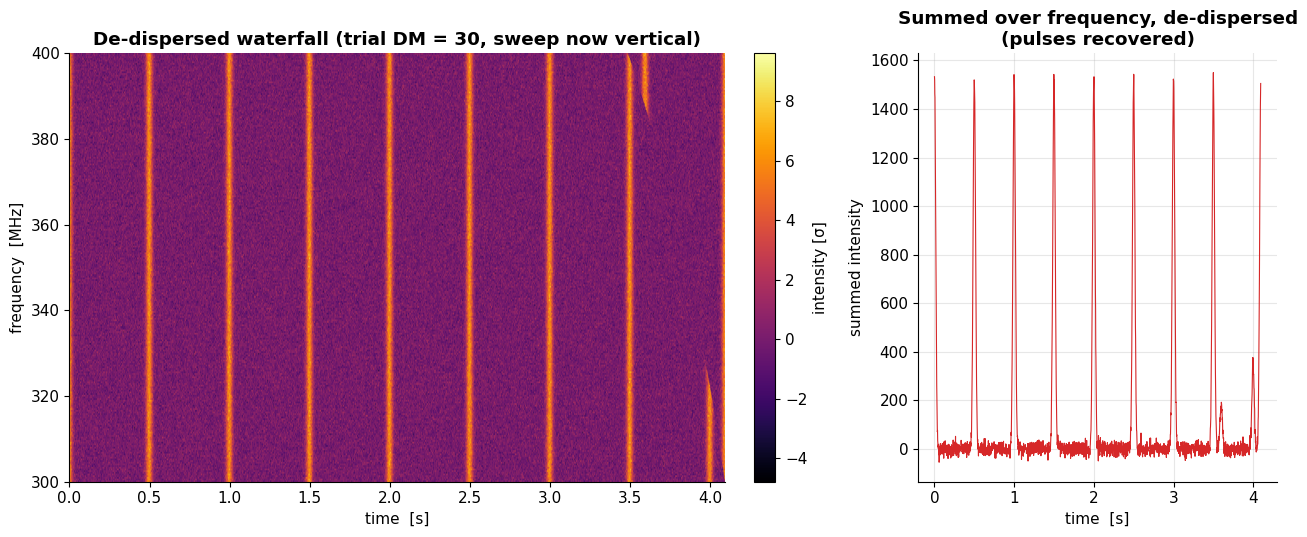

In [6]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13, 5.5), gridspec_kw={"width_ratios": [2, 1]})

im = ax0.imshow(dd.T, aspect="auto", extent=extent, origin="lower")
ax0.set_xlabel("time  [s]")
ax0.set_ylabel("frequency  [MHz]")
ax0.set_title(f"De-dispersed waterfall (trial DM = {DM_true.value:.0f}, sweep now vertical)")
ax0.grid(False)
fig.colorbar(im, ax=ax0, fraction=0.046, pad=0.04, label="intensity [σ]")

ax1.plot(times.value, ts_dedispersed, lw=0.8, color="#d62728")
ax1.set_xlabel("time  [s]")
ax1.set_ylabel("summed intensity")
ax1.set_title("Summed over frequency, de-dispersed\n(pulses recovered)")

plt.tight_layout()
plt.show()

## Folding: stacking rotations to build signal-to-noise

Even de-dispersed, a single pulse may be only marginally above the noise. But the
pulsar is a superb clock, so every pulse sits at the **same phase** within each
period $P$. **Folding** exploits this: we compute each time sample's **pulse
phase** $\phi = (t / P) \bmod 1$, bin the samples by phase, and average. The
phase-locked pulse reinforces; the white noise averages down as
$\sqrt{N_\mathrm{rot}}$ where $N_\mathrm{rot}$ is the number of rotations folded.
The result is the **average pulse profile**.

In [7]:
def fold(time_series, times, period, n_bins=64):
    """Fold a 1-D time series at `period` into `n_bins` of pulse phase."""
    phase = ((times / period).decompose().value) % 1.0
    bins = np.floor(phase * n_bins).astype(int)
    bins = np.clip(bins, 0, n_bins - 1)
    profile = np.zeros(n_bins)
    counts = np.zeros(n_bins)
    np.add.at(profile, bins, time_series)
    np.add.at(counts, bins, 1.0)
    counts[counts == 0] = 1.0
    return profile / counts


n_bins = 64
phase_axis = (np.arange(n_bins) + 0.5) / n_bins
profile_dd = fold(ts_dedispersed, times, P, n_bins=n_bins)
profile_raw = fold(ts_dispersed, times, P, n_bins=n_bins)

n_rot = (times[-1] / P).decompose().value
print(f"folded {n_rot:.0f} rotations into {n_bins} phase bins")

folded 8 rotations into 64 phase bins


The folded profile below makes the payoff visible. Folding the **de-dispersed**
series gives a clean, narrow pulse standing well above the baseline; folding the
**dispersed** series gives a low, smeared bump — same data, but the dispersion
delay scrambled the phase alignment across the band. De-dispersion *then* folding
is the canonical pulsar detection pipeline, and it is how Bell and Hewish turned
"a bit of scruff" into an unambiguous astronomical clock.

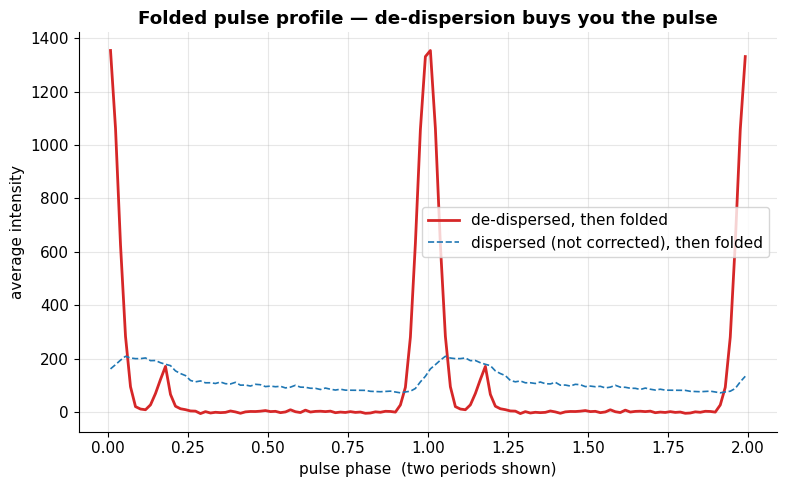

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
# Plot two periods side by side so the pulse shape reads clearly.
two_phase = np.concatenate([phase_axis, phase_axis + 1.0])
ax.plot(
    two_phase, np.tile(profile_dd, 2), lw=2.0, color="#d62728", label="de-dispersed, then folded"
)
ax.plot(
    two_phase,
    np.tile(profile_raw, 2),
    lw=1.2,
    ls="--",
    color="#1f77b4",
    label="dispersed (not corrected), then folded",
)
ax.set_xlabel("pulse phase  (two periods shown)")
ax.set_ylabel("average intensity")
ax.set_title("Folded pulse profile — de-dispersion buys you the pulse")
ax.legend()
plt.tight_layout()
plt.show()

## Pulsar timing, in one paragraph

Once you have a folded profile you have a **template** — the average pulse shape.
**Pulsar timing** is the art of measuring, observation after observation, the
exact arrival time of the pulse (the *time of arrival*, or TOA) by cross-matching
each profile against that template, and then fitting a model that predicts every
TOA. The model accounts for the pulsar's spin period and its slow-down
($P,\dot P$), the motion of the Earth around the Solar System barycentre, the
DM and its variation, and — for pulsars in binaries — the orbit. A good timing
solution predicts arrival times to better than a **microsecond** over years,
which makes pulsars precision tools: they have confirmed the orbital decay of a
binary from gravitational-wave emission (Hulse–Taylor), they constrain the
neutron-star equation of state, and arrays of millisecond pulsars (Pulsar Timing
Arrays) are now detecting the **nanohertz gravitational-wave background**. The
standard open-source engine for this is **PINT** (`pint-pulsar`).

## Try it yourself

Two scaffolded exercises. Each runs as-is (it reuses values computed above), but
the learning happens when you fill in the `# TODO` lines and compare. They use
only the base-environment simulation — no network, no extras.

### Exercise 1 — Search over trial DMs

In a real survey you **do not know** the DM in advance; you de-disperse at many
trial DMs and keep the one that maximises the signal. **Build a DM curve**:
de-disperse the simulated waterfall at a grid of trial DMs, fold each result, and
record the **peak of the folded profile**. The peak should rise to a maximum at
the true DM (≈ 30) and fall off on either side. Add finer/wider trial DMs and see
how sharply the peak is localised.

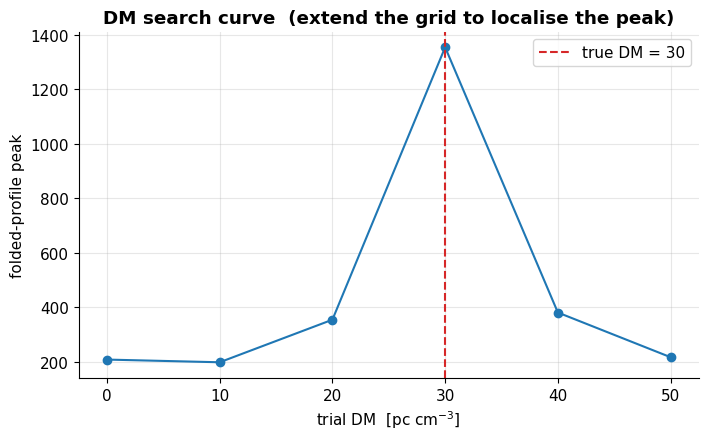

In [9]:
# TODO: sweep the trial DM and find where the folded pulse is strongest.
#       Fill in / widen `trial_dms`, then de-disperse + fold at each and record
#       the folded-profile peak. Where does the curve peak? (Should be ~30.)

trial_dms = np.array([0, 10, 20, 30, 40, 50])  # TODO: try a finer grid, e.g. np.arange(0, 60, 2)

peaks = []
for dm_val in trial_dms:
    dm_q = dm_val * u.pc / u.cm**3
    dd_trial = dedisperse(waterfall, freqs, dm_q, f_hi, t_samp)
    prof = fold(dd_trial.sum(axis=1), times, P, n_bins=n_bins)
    # TODO: experiment with (peak - median) / std as a more robust detection stat.
    peaks.append(prof.max())

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(trial_dms, peaks, "o-", color="#1f77b4")
ax.axvline(DM_true.value, color="#d62728", ls="--", label=f"true DM = {DM_true.value:.0f}")
ax.set_xlabel("trial DM  [pc cm$^{-3}$]")
ax.set_ylabel("folded-profile peak")
ax.set_title("DM search curve  (extend the grid to localise the peak)")
ax.legend()
plt.show()

<details>
<summary>Solution</summary>

The scaffold already has the right loop; the exercise is to (1) widen and refine
`trial_dms` and (2) swap the raw peak for a more robust detection statistic. A
finer grid localises where the folded pulse is strongest, which should land on
the true DM.

```python
# Fine, wide DM grid.
trial_dms = np.arange(0.0, 60.0, 0.5)

def detection_snr(profile):
    # Robust peak significance: how far the peak bin sticks out of the
    # baseline, in units of the off-pulse scatter.
    return (profile.max() - np.median(profile)) / profile.std()

snrs = []
for dm_val in trial_dms:
    dm_q = dm_val * u.pc / u.cm**3
    dd_trial = dedisperse(waterfall, freqs, dm_q, f_hi, t_samp)
    prof = fold(dd_trial.sum(axis=1), times, P, n_bins=n_bins)
    snrs.append(detection_snr(prof))
snrs = np.array(snrs)

best_dm = trial_dms[np.argmax(snrs)]
print(f"best trial DM = {best_dm:.1f} pc/cm^3  (true = {DM_true.value:.0f})")
```

Running this reuses the chapter's own `dedisperse` and `fold` helpers and
recovers the input value: the detection statistic peaks at
**DM ≈ 30 pc cm$^{-3}$**, exactly the `DM_true` we injected. (Both the raw
`prof.max()` and the robust $(\text{peak}-\text{median})/\sigma$ peak at the same
place here; the robust statistic just keeps the *baseline* flat so the peak is
unambiguous.)

**How sharply is the peak localised?** Two ways to see it:

- *Empirically*, sampling the curve on a fine grid near the peak, the detection
  statistic is above its half-power value over roughly $27 \le \mathrm{DM} \le 33$
  — a **FWHM of about $6\ \mathrm{pc\,cm^{-3}}$** at this S/N.
- *Analytically*, a DM error $\delta\mathrm{DM}$ leaves a residual sweep across
  the band of
  $$
  \Delta t \;=\; \mathcal{D}\,\delta\mathrm{DM}\,
      \left(\nu_\mathrm{lo}^{-2}-\nu_\mathrm{hi}^{-2}\right),
  $$
  which for our $300$–$400$ MHz band is $\approx 20\ \mathrm{ms}$ per unit DM.
  The pulse itself has FWHM $\approx 2.355\,(\text{duty})\,P \approx 35\
  \mathrm{ms}$. The de-dispersion starts to smear once the residual sweep is
  comparable to the pulse width, i.e. once
  $$
  \delta\mathrm{DM}\;\approx\;\frac{35\ \mathrm{ms}}{20\ \mathrm{ms/(pc\,cm^{-3})}}
      \;\approx\;1.8\ \mathrm{pc\,cm^{-3}}.
  $$
  So the curve has a well-defined peak a couple of $\mathrm{pc\,cm^{-3}}$ wide,
  set by the *band width* and the *pulse width*: a wider band, or a narrower
  pulse, pins the DM down more tightly. This $\Delta t \propto
  \delta\mathrm{DM}\,(\nu_\mathrm{lo}^{-2}-\nu_\mathrm{hi}^{-2})$ scaling is the
  same one that makes high-DM, low-frequency surveys need very fine DM grids.

</details>

### Exercise 2 — Vary the period (and try folding at the wrong one)

Folding only builds signal-to-noise if you fold at the **right** period. **Change
`P_fold`** away from the true period `P` and watch the folded profile degrade:
fold at the true period for a sharp pulse, fold at a slightly wrong period and the
pulse drifts in phase from rotation to rotation and smears out. This is why
period (and period-derivative) searching matters as much as DM searching.

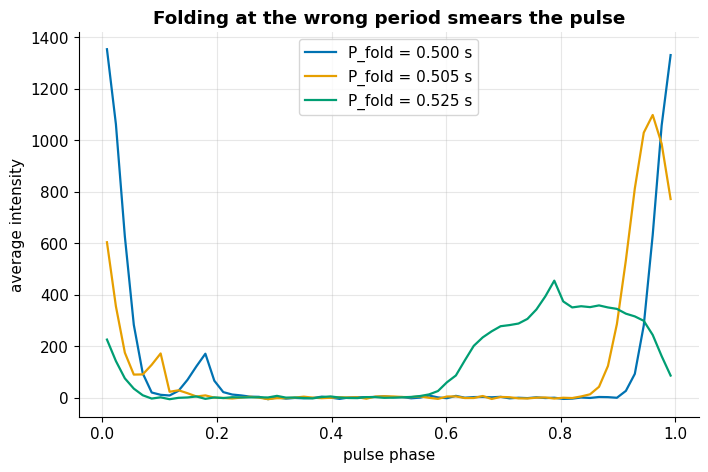

In [10]:
# TODO: fold the de-dispersed series at several periods and compare the profiles.
#       Start exactly at P, then detune by a few percent and watch the pulse
#       smear. What fractional period error noticeably broadens the pulse?

P_fold_values = [P, 1.01 * P, 1.05 * P]  # TODO: add e.g. 0.95*P, 1.10*P

fig, ax = plt.subplots(figsize=(8, 5))
for P_fold in P_fold_values:
    prof = fold(ts_dedispersed, times, P_fold, n_bins=n_bins)
    label = f"P_fold = {P_fold.to(u.s).value:.3f} s"
    ax.plot(phase_axis, prof, lw=1.6, label=label)
ax.set_xlabel("pulse phase")
ax.set_ylabel("average intensity")
ax.set_title("Folding at the wrong period smears the pulse")
ax.legend()
plt.show()

<details>
<summary>Solution</summary>

Add a spread of fold periods around the true `P` and watch the folded profile
collapse as the period is detuned:

```python
P_fold_values = [0.90 * P, 0.95 * P, 0.99 * P, P, 1.01 * P, 1.05 * P, 1.10 * P]

def detection_snr(profile):
    return (profile.max() - np.median(profile)) / profile.std()

for P_fold in P_fold_values:
    prof = fold(ts_dedispersed, times, P_fold, n_bins=n_bins)
    frac = (P_fold / P).decompose().value - 1.0
    print(f"P_fold = {P_fold.to(u.s).value:.4f} s  (dP/P = {frac:+.1%})  "
          f"peak/sigma = {detection_snr(prof):.1f}")
```

Folding at the true period gives the sharpest, tallest pulse; detuning broadens
and lowers it. Running it:

| $\delta P/P$ | folded peak/$\sigma$ |
|---|---|
| $0\%$ (true $P$) | $\approx 4.4$ |
| $\pm 1\%$ | $\approx 4.1$ |
| $\pm 5\%$ | $\approx 3.0$ |
| $\pm 10\%$ | $\approx 2.0$ |

**Why it smears — and at what fractional error.** If you fold at a period that is
wrong by $\delta P$, then over one rotation the pulse arrives at a phase offset by
$\delta P / P$, and after $N_\mathrm{rot}$ rotations the accumulated phase drift
is
$$
\Delta\phi \;\approx\; N_\mathrm{rot}\,\frac{\delta P}{P}.
$$
The pulse stays sharp only while this drift is smaller than the pulse width
(here the fractional duty cycle, `duty` $= 0.03$). So the tolerance is

$$
\left|\frac{\delta P}{P}\right| \;\lesssim\; \frac{\text{duty}}{N_\mathrm{rot}}.
$$

This observation spans $T \approx 4.1$ s $= N_\mathrm{rot}\approx 8$ rotations
(`times[-1] / P`), so the period must be right to within
$$
\frac{\delta P}{P} \;\lesssim\; \frac{0.03}{8} \;\approx\; 0.4\%,
$$
which is exactly why even the $\pm 1\%$ row above is already visibly degraded
while $\pm 5$–$10\%$ is essentially washed out. The crucial lesson: the
*longer* you integrate (larger $N_\mathrm{rot}$), the *more* sharply the period
is constrained — a long observation is a precise clock, but it also demands a
finer period search. This is the period analogue of the DM search in Exercise 1,
and together a 2-D search over $(\mathrm{DM}, P)$ (often extended to $\dot P$) is
how blind pulsar surveys find new pulsars.

</details>

## From simulation to real data (the optional `pulsar` extra)

Everything above was simulated so it runs offline. To work with **real** pulsar
data you install the optional extra and reach for the standard archives:

```bash
uv sync --extra pulsar     # installs pint-pulsar and your
```

- **`your`** (Your Unified Reader) reads **PSRFITS** and **SIGPROC filterbank**
  files into exactly the `(time, frequency)` dynamic spectra we simulated, and
  ships de-dispersion/folding utilities — drop a real file in place of
  `waterfall` and the same pipeline runs.
- **`pint-pulsar` (PINT)** is the modern Python pulsar-timing package: it reads
  `.par` timing models and `.tim` TOA files, computes barycentred arrival times,
  and fits $P,\dot P$, DM, and binary parameters.
- **Archives.** Real time-domain and folded pulsar data live at
  **HEASARC** ([heasarc.gsfc.nasa.gov](https://heasarc.gsfc.nasa.gov/)), and the
  **European Pulsar Network (EPN) Database of Pulsar Profiles**
  ([www.epta.eu.org/epndb](http://www.epta.eu.org/epndb/)) hosts published
  average profiles for thousands of pulsars across many frequencies — a great
  place to see real versions of the folded profile we built.

The cell below shows the *shape* of that real-data path, guarded so it is a no-op
on the base environment.

In [11]:
# Guarded peek at the real-data path. No-op (and no network) unless you have
# installed the `pulsar` extra AND point `psrfits_path` at a local file.
psrfits_path = None  # TODO: set to a local .fits / .fil path after `uv sync --extra pulsar`

if HAVE_YOUR and psrfits_path is not None:
    from your import Your

    yr = Your(psrfits_path)
    real_waterfall = yr.get_data(nstart=0, nsamp=n_time)  # (time, freq)
    print("loaded real dynamic spectrum:", real_waterfall.shape)
    # The dedisperse() / fold() helpers above work unchanged on real_waterfall,
    # using yr.chan_freqs for the channel frequencies and yr.your_header.tsamp
    # for the sampling time.
else:
    print(
        "Real-data path skipped (base env / no file). "
        "Install with `uv sync --extra pulsar` and set psrfits_path to try it."
    )

Real-data path skipped (base env / no file). Install with `uv sync --extra pulsar` and set psrfits_path to try it.


### A real timing fit you can run now

The peek above needs a file *you* supply. Here is a real fit that runs end to end
on **bundled** data: PINT timing of **PSR J1748−2021E**, a 16-ms pulsar in the
globular cluster **NGC 6440**, on real **NANOGrav** times of arrival (PINT's own
example dataset, registered in `jansky.data`). We load the `.par` timing model and
`.tim` TOAs, fit, and plot the **timing residuals** — the microsecond-level
differences between observed and predicted pulse arrival times. A good fit leaves
residuals no larger than the TOA measurement errors; those residuals are exactly
what the **pulsar timing arrays** of [Chapter 20](20_pulsar_timing_arrays.ipynb)
cross-correlate between pulsars to hunt for nanohertz gravitational waves.


J1748-2021E in NGC 6440  |  62 TOAs over 709 days
spin frequency F0 = 61.485477 Hz  (P = 16.264 ms)
post-fit weighted residual RMS = 21.18 us  (~ the 22 us TOA measurement errors)


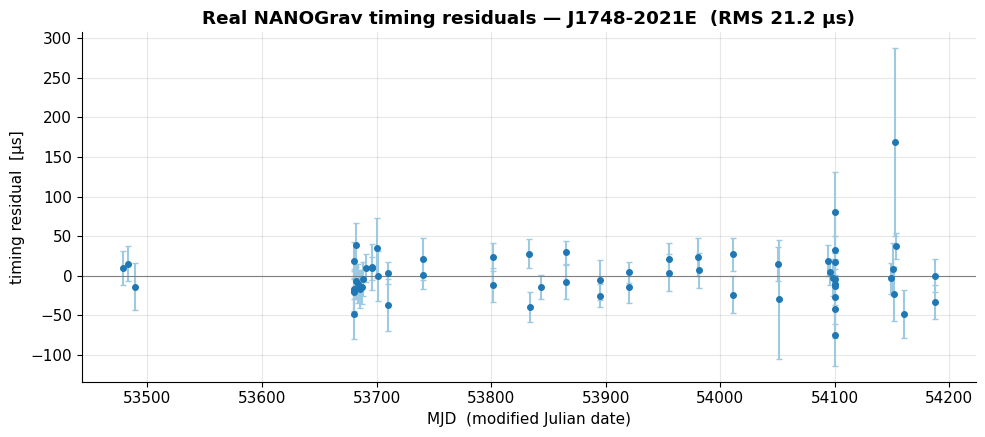

In [12]:
# A REAL timing fit: PINT on real NANOGrav TOAs for PSR J1748-2021E (in NGC 6440).
# Runs with the `pulsar` extra installed and a network for the one-time ephemeris
# download; otherwise it degrades to a note and the simulated pipeline stands.
if not HAVE_PINT:
    print(
        "Real PINT timing skipped: install the `pulsar` extra "
        "(`uv sync --extra pulsar`) and re-run."
    )
else:
    try:
        import pint.logging

        pint.logging.setup(level="WARNING")  # quiet PINT's very verbose logging

        import pint.toa as toa
        from pint.fitter import WLSFitter
        from pint.models import get_model

        from jansky import data

        model = get_model(str(data.fetch("pint-ngc6440e-par")))
        toas = toa.get_TOAs(str(data.fetch("pint-ngc6440e-tim")))  # downloads DE421 once
        fitter = WLSFitter(toas, model)
        fitter.fit_toas()

        mjd = toas.get_mjds().value
        resid_us = fitter.resids.time_resids.to(u.us).value
        err_us = toas.get_errors().to(u.us).value
        rms = fitter.resids.rms_weighted().to(u.us).value
        psr = f"J{model.PSR.value}"

        print(f"{psr} in NGC 6440  |  {toas.ntoas} TOAs over {mjd.max() - mjd.min():.0f} days")
        print(f"spin frequency F0 = {model.F0.value:.6f} Hz  (P = {1e3 / model.F0.value:.3f} ms)")
        print(
            f"post-fit weighted residual RMS = {rms:.2f} us  "
            f"(~ the {np.median(err_us):.0f} us TOA measurement errors)"
        )

        fig, ax = plt.subplots(figsize=(10, 4.5))
        ax.errorbar(
            mjd, resid_us, yerr=err_us, fmt="o", ms=4, color="#1f77b4", ecolor="#9ecae1", capsize=2
        )
        ax.axhline(0.0, color="0.5", lw=0.8)
        ax.set_xlabel("MJD  (modified Julian date)")
        ax.set_ylabel("timing residual  [µs]")
        ax.set_title(f"Real NANOGrav timing residuals — {psr}  (RMS {rms:.1f} µs)")
        plt.tight_layout()
        plt.show()
    except Exception as exc:
        print(f"Real PINT timing skipped: {type(exc).__name__}: {exc}")
        print("(Needs a network for the one-time ephemeris download.)")

## Recap

- A **pulsar** is a rapidly rotating, strongly magnetised **neutron star**; its
  beam sweeps across us like a **lighthouse**, so the observed pulse period is the
  star's **spin period $P$**. Discovered by **Bell & Hewish (1968)**.
- The cold ISM plasma is **dispersive**: a broadband pulse is delayed by
  $t(\nu) = \mathcal{D}\,\mathrm{DM}\,\nu^{-2}$, with
  $\mathcal{D} \approx 4148.808\ \mathrm{MHz^2\,cm^3\,pc^{-1}\,s}$ and the
  **dispersion measure** $\mathrm{DM} = \int n_e\,\mathrm{d}l$ the electron column.
- A raw observation is a **dynamic spectrum** (time × frequency); dispersion shows
  up as a **curved sweep** that washes out the pulse if uncorrected.
- **De-dispersion** shifts each channel back by its delay so the sweep becomes
  vertical; **folding** at the period $P$ stacks rotations so the pulse adds while
  noise averages down as $\sqrt{N_\mathrm{rot}}$, yielding the **pulse profile**.
- A **DM search** (try many trial DMs) and a **period search** (try many periods)
  are how blind surveys find pulsars — Exercises 1 and 2.
- **Pulsar timing** fits arrival times to sub-microsecond precision and turns
  pulsars into clocks for tests of gravity and gravitational-wave detection
  (PINT, `pint-pulsar`).

### What's next

This is the final research chapter of the arc. From a single antenna's noisy
voltage (Chapters 1–6), through interferometry and imaging (Chapters 7–10), to
spectral lines (Chapter 11) and now time-domain astronomy (Chapter 13), you have
walked the full path from raw radio signal to science. To go further with
pulsars, install the `pulsar` extra, pull a profile from the EPN database or a
filterbank from HEASARC, and run the very same `dedisperse` / `fold` pipeline on
real bytes.

<!-- glossary-footer -->

---

## 📖 Glossary

Terms from this chapter — follow a link to look it up in the [course glossary](../docs/glossary.md):

[Baseline](../docs/glossary.md#baseline) ·
[Beam](../docs/glossary.md#beam) ·
[De-dispersion](../docs/glossary.md#de-dispersion) ·
[Dispersion measure](../docs/glossary.md#dispersion-measure) ·
[Dynamic spectrum](../docs/glossary.md#dynamic-spectrum) ·
[FWHM](../docs/glossary.md#fwhm) ·
[Interstellar medium](../docs/glossary.md#interstellar-medium) ·
[Nanohertz gravitational waves](../docs/glossary.md#nanohertz-gravitational-waves) ·
[Neutron star](../docs/glossary.md#neutron-star) ·
[Plasma](../docs/glossary.md#plasma) ·
[Pulsar](../docs/glossary.md#pulsar) ·
[Sidereal time](../docs/glossary.md#sidereal-time)
